# Actividad 2: Calidad, Drift y Anomalías
## Análisis de Datos II - CEIA 4B2026

**Dataset:** [Data Science Salaries 2023](https://www.kaggle.com/datasets/arnabchaki/data-science-salaries-2023)

**Objetivo:** dividir el dataset en un período de referencia y uno actual, evaluar la calidad de los datos,
medir drift con PSI y detectar anomalías con Isolation Forest y LOF.

El modelo de referencia es el de la Actividad 1: un `RandomForestRegressor` con hiperparámetros por
defecto que predice `salary_in_usd`, entrenado sin las variables `salary` y `salary_currency`, que allí
se identificaron como fuga de información.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor, IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.preprocessing import OrdinalEncoder, StandardScaler
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

## 1. Carga y partición en períodos

In [2]:
df = pd.read_csv('data/ds_salaries.csv')
print(f'Dataset completo: {df.shape[0]} filas, {df.shape[1]} columnas')
print(f'Años presentes: {sorted(df.work_year.unique())}')
df.head()

Dataset completo: 3755 filas, 11 columnas
Años presentes: [np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023)]


,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size
0,2023,SE,FT,Principal Data Scientist,80000,EUR,85847,ES,100,ES,L
1,2023,MI,CT,ML Engineer,30000,USD,30000,US,100,US,S
2,2023,MI,CT,ML Engineer,25500,USD,25500,US,100,US,S
3,2023,SE,FT,Data Scientist,175000,USD,175000,CA,100,CA,M
4,2023,SE,FT,Data Scientist,120000,USD,120000,CA,100,CA,M


In [3]:
# Partición pedida por la consigna
referencia = df[df.work_year.isin([2020, 2021])].copy()
actual     = df[df.work_year.isin([2022, 2023])].copy()

resumen = pd.DataFrame({
    'periodo':   ['Referencia (2020-2021)', 'Actual (2022-2023)'],
    'filas':     [len(referencia), len(actual)],
    'proporcion':[f'{len(referencia)/len(df):.1%}', f'{len(actual)/len(df):.1%}'],
})
print(resumen.to_string(index=False))

print('\nDistribución por año:')
print(df.work_year.value_counts().sort_index().to_string())

               periodo  filas proporcion
Referencia (2020-2021)    306       8.1%
    Actual (2022-2023)   3449      91.9%

Distribución por año:
work_year
2020      76
2021     230
2022    1664
2023    1785


La partición queda muy desbalanceada: la referencia reúne el 8% de los registros y la actual el 92%.
Esto no invalida la comparación, pero sí condiciona la lectura del PSI, porque con 306 observaciones
los bins de referencia tienen poca masa y el índice se vuelve más sensible. Lo tenemos en cuenta al
fijar el umbral.

## 2. Calidad de datos

Se eligen cuatro variables relevantes, las mismas que sugiere la consigna, y se aplican cinco chequeos
de calidad sobre cada período por separado. Cada chequeo corresponde a una dimensión de calidad de las
vistas en clase.

In [4]:
VARS = ['salary_in_usd', 'experience_level', 'remote_ratio', 'company_size']

# Dominios válidos declarados para los chequeos de validez
DOMINIOS = {
    'experience_level': {'EN', 'MI', 'SE', 'EX'},
    'company_size':     {'S', 'M', 'L'},
    'remote_ratio':     {0, 50, 100},
}

def chequeos_calidad(datos, nombre):
    filas = len(datos)
    res = []

    # 1. Completitud: ninguna de las variables elegidas debe tener nulos
    nulos = datos[VARS].isna().sum().sum()
    res.append(('Completitud', 'Sin nulos en las variables elegidas', nulos == 0, f'{nulos} nulos'))

    # 2. Unicidad: no debería haber filas repetidas en su totalidad
    dups = datos.duplicated().sum()
    res.append(('Unicidad', 'Sin filas duplicadas', dups == 0, f'{dups} duplicados ({dups/filas:.1%})'))

    # 3. Validez de dominio: las categóricas solo toman valores declarados
    fuera = {c: sorted(set(datos[c].unique()) - set(v)) for c, v in DOMINIOS.items()}
    invalidos = {c: v for c, v in fuera.items() if v}
    res.append(('Validez', 'Categorías dentro del dominio declarado', not invalidos,
                'ninguna fuera de dominio' if not invalidos else str(invalidos)))

    # 4. Rango: un salario anual en USD debe ser positivo y razonable
    fuera_rango = ((datos.salary_in_usd <= 0) | (datos.salary_in_usd > 1_000_000)).sum()
    res.append(('Rango', 'salary_in_usd dentro de (0, 1.000.000]', fuera_rango == 0,
                f'{fuera_rango} fuera de rango'))

    # 5. Consistencia: si la moneda es USD, salary y salary_in_usd deben coincidir
    usd = datos[datos.salary_currency == 'USD']
    incons = (usd.salary != usd.salary_in_usd).sum()
    res.append(('Consistencia', 'salary == salary_in_usd cuando la moneda es USD', incons == 0,
                f'{incons} inconsistentes sobre {len(usd)} filas en USD'))

    out = pd.DataFrame(res, columns=['dimension', 'chequeo', 'pasa', 'detalle'])
    out.insert(0, 'periodo', nombre)
    return out

calidad = pd.concat([chequeos_calidad(referencia, 'Referencia'),
                     chequeos_calidad(actual, 'Actual')], ignore_index=True)
calidad['pasa'] = calidad['pasa'].map({True: 'OK', False: 'FALLA'})
print(calidad.to_string(index=False))

   periodo    dimension                                         chequeo  pasa                                  detalle
Referencia  Completitud             Sin nulos en las variables elegidas    OK                                  0 nulos
Referencia     Unicidad                            Sin filas duplicadas FALLA                      3 duplicados (1.0%)
Referencia      Validez         Categorías dentro del dominio declarado    OK                 ninguna fuera de dominio
Referencia        Rango          salary_in_usd dentro de (0, 1.000.000]    OK                         0 fuera de rango
Referencia Consistencia salary == salary_in_usd cuando la moneda es USD    OK  0 inconsistentes sobre 160 filas en USD
    Actual  Completitud             Sin nulos en las variables elegidas    OK                                  0 nulos
    Actual     Unicidad                            Sin filas duplicadas FALLA                  1168 duplicados (33.9%)
    Actual      Validez         Categorías dentr

In [5]:
# El chequeo de unicidad es el único que falla: lo miramos de cerca
dups_ref = referencia[referencia.duplicated(keep=False)].sort_values(VARS)
dups_act = actual[actual.duplicated(keep=False)].sort_values(VARS)

print(f'Filas involucradas en duplicados - referencia: {len(dups_ref)}, actual: {len(dups_act)}')
print('\nEjemplo de grupo duplicado en el período actual:')
ejemplo = actual[actual.duplicated(keep=False)].groupby(list(df.columns)).size().sort_values(ascending=False).head(3)
print(ejemplo.to_string())

Filas involucradas en duplicados - referencia: 6, actual: 1709

Ejemplo de grupo duplicado en el período actual:
work_year  experience_level  employment_type  job_title       salary  salary_currency  salary_in_usd  employee_residence  remote_ratio  company_location  company_size
2022       SE                FT               Data Scientist  191475  USD              191475         US                  100           US                M               21
                                                              141525  USD              141525         US                  100           US                M               21
2023       SE                FT               Data Engineer   252000  USD              252000         US                  0             US                M               13


### Lectura de los chequeos

Cuatro de los cinco chequeos pasan en ambos períodos: no hay nulos, las categóricas respetan su
dominio, los salarios caen en un rango plausible y `salary_in_usd` coincide con `salary` cuando la
moneda ya es USD, lo que da confianza en la conversión.

El que falla es **unicidad**, y falla de manera muy desigual: 1.0% de filas duplicadas en la
referencia contra **33.9% en el período actual**, con 1709 filas involucradas. El dataset no tiene
una columna identificadora, así que una fila repetida puede ser tanto un registro cargado dos veces
como dos personas distintas que comparten puesto, seniority, país, modalidad y salario exacto. El
ejemplo que se imprime arriba muestra 21 registros idénticos de `Data Scientist` senior en Estados
Unidos con el mismo salario, lo que hace más verosímil la duplicación que la coincidencia.

Importa para el modelado, no solo para la prolijidad: si las filas repetidas se reparten entre
entrenamiento y test, el modelo ve en test ejemplos que ya memorizó y las métricas quedan infladas.
Es el mismo tipo de problema que la fuga de información de la Actividad 1, por otra vía.

**Acción:** deduplicar antes de entrenar, o al menos separar por grupos para que las copias no crucen
la frontera entre entrenamiento y test. Como el impacto se concentra en el período actual, no
corregirlo sesgaría cualquier comparación entre períodos.

## 3. Drift: cálculo de PSI

In [6]:
def psi(base, comparacion, bins=10, es_categorica=False):
    """Population Stability Index entre una muestra de referencia y una actual.

    Para variables numéricas los cortes se definen por deciles de la referencia, que es la
    convención habitual: la referencia es la que fija la grilla. Para categóricas cada categoría
    es un bin. Se aplica una corrección epsilon para evitar divisiones por cero cuando una
    categoría no aparece en alguno de los dos períodos.
    """
    eps = 1e-6
    if es_categorica:
        categorias = sorted(set(base.dropna().unique()) | set(comparacion.dropna().unique()))
        p_base = np.array([(base == c).mean() for c in categorias], dtype=float)
        p_comp = np.array([(comparacion == c).mean() for c in categorias], dtype=float)
        etiquetas = [str(c) for c in categorias]
    else:
        cortes = np.unique(np.quantile(base.dropna(), np.linspace(0, 1, bins + 1)))
        cortes[0], cortes[-1] = -np.inf, np.inf
        p_base = np.histogram(base.dropna(), bins=cortes)[0] / len(base.dropna())
        p_comp = np.histogram(comparacion.dropna(), bins=cortes)[0] / len(comparacion.dropna())
        etiquetas = [f'({cortes[i]:,.0f}, {cortes[i+1]:,.0f}]' for i in range(len(cortes) - 1)]

    p_base = np.where(p_base == 0, eps, p_base)
    p_comp = np.where(p_comp == 0, eps, p_comp)
    aportes = (p_comp - p_base) * np.log(p_comp / p_base)
    detalle = pd.DataFrame({'bin': etiquetas, 'p_referencia': p_base,
                            'p_actual': p_comp, 'aporte_psi': aportes})
    return float(aportes.sum()), detalle


ES_CATEGORICA = {'salary_in_usd': False, 'experience_level': True,
                 'remote_ratio': True, 'company_size': True}

resultados, detalles = [], {}
for v in VARS:
    valor, det = psi(referencia[v], actual[v], es_categorica=ES_CATEGORICA[v])
    resultados.append({'variable': v, 'psi': valor})
    detalles[v] = det

psi_tabla = pd.DataFrame(resultados).sort_values('psi', ascending=False)
print(psi_tabla.to_string(index=False))

        variable      psi
    company_size 2.198147
    remote_ratio 1.191421
   salary_in_usd 0.863169
experience_level 0.741723


        variable      psi interpretacion
    company_size 2.198147   drift severo
    remote_ratio 1.191421   drift severo
   salary_in_usd 0.863169   drift severo
experience_level 0.741723   drift severo


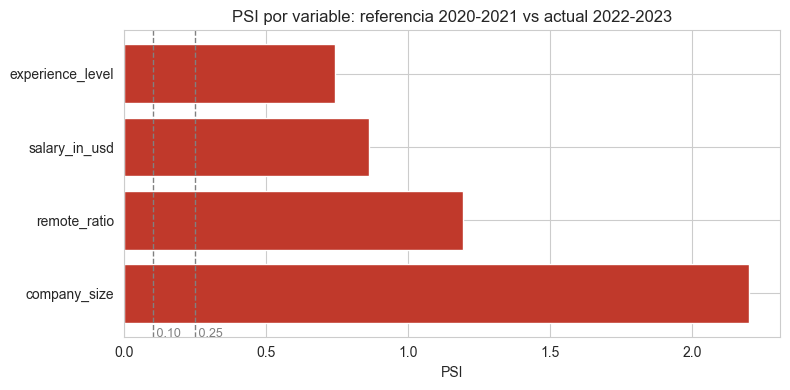

In [7]:
# Umbrales clásicos de PSI
def clasificar(valor):
    if valor < 0.10:  return 'sin drift'
    if valor < 0.25:  return 'drift moderado'
    return 'drift severo'

psi_tabla['interpretacion'] = psi_tabla.psi.apply(clasificar)
print(psi_tabla.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
colores = psi_tabla.psi.apply(lambda v: '#c0392b' if v >= 0.25 else ('#e67e22' if v >= 0.10 else '#27ae60'))
ax.barh(psi_tabla.variable, psi_tabla.psi, color=colores)
ax.axvline(0.10, ls='--', c='gray', lw=1)
ax.axvline(0.25, ls='--', c='gray', lw=1)
ax.text(0.10, -0.6, ' 0.10', color='gray', fontsize=9)
ax.text(0.25, -0.6, ' 0.25', color='gray', fontsize=9)
ax.set_xlabel('PSI')
ax.set_title('PSI por variable: referencia 2020-2021 vs actual 2022-2023')
plt.tight_layout(); plt.show()

In [8]:
# Detalle del PSI de la variable con mayor desplazamiento
peor = psi_tabla.iloc[0].variable
print(f'Aporte de cada bin al PSI de {peor}:\n')
print(detalles[peor].to_string(index=False, float_format=lambda x: f'{x:.4f}'))

Aporte de cada bin al PSI de company_size:

bin  p_referencia  p_actual  aporte_psi
  L        0.5294    0.0847      0.8153
  M        0.2353    0.8933      0.8778
  S        0.2353    0.0220      0.5050


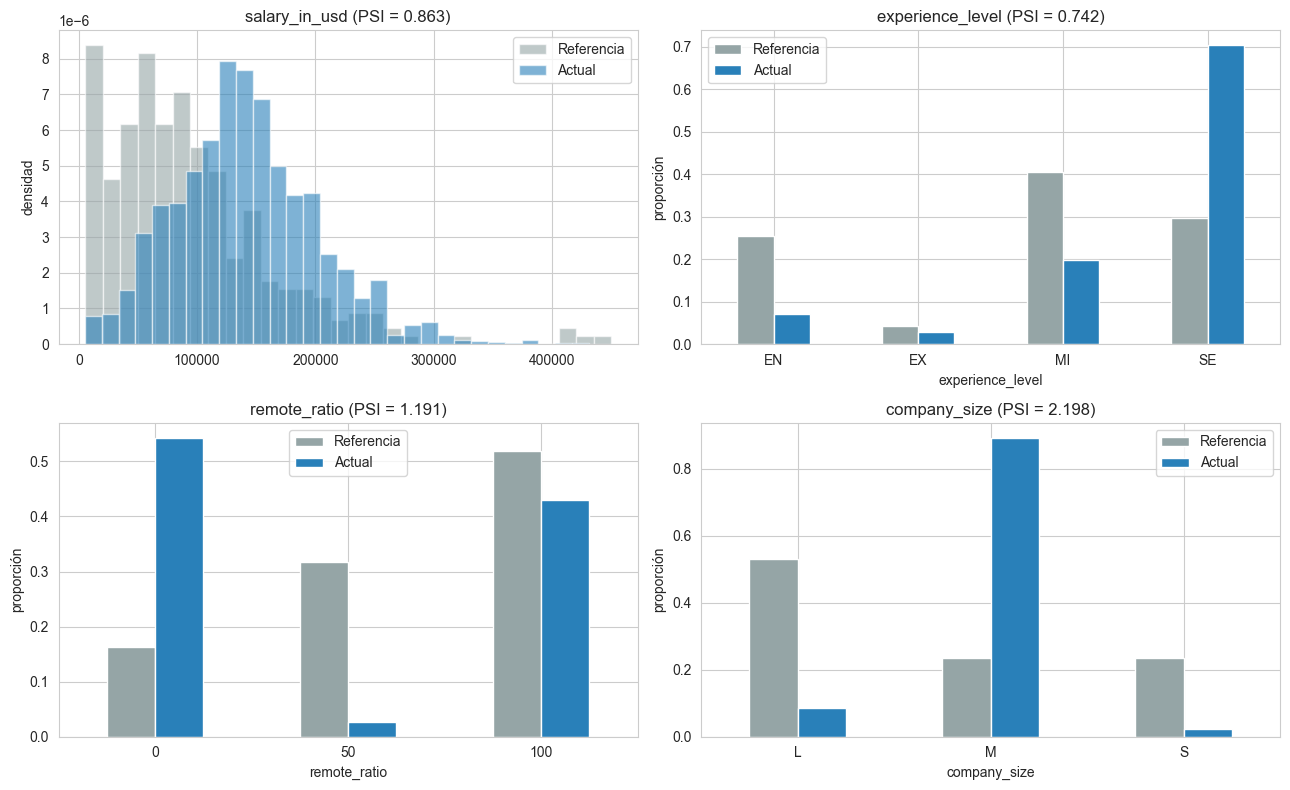

In [9]:
# Distribuciones comparadas
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, v in zip(axes.ravel(), VARS):
    if ES_CATEGORICA[v]:
        comp = pd.DataFrame({
            'Referencia': referencia[v].value_counts(normalize=True),
            'Actual':     actual[v].value_counts(normalize=True)}).fillna(0).sort_index()
        comp.plot(kind='bar', ax=ax, color=['#95a5a6', '#2980b9'], rot=0)
        ax.set_ylabel('proporción')
    else:
        ax.hist(referencia[v], bins=30, density=True, alpha=0.6, label='Referencia', color='#95a5a6')
        ax.hist(actual[v], bins=30, density=True, alpha=0.6, label='Actual', color='#2980b9')
        ax.legend(); ax.set_ylabel('densidad')
    ax.set_title(f'{v} (PSI = {psi_tabla.set_index("variable").loc[v, "psi"]:.3f})')
plt.tight_layout(); plt.show()

### Interpretación del drift

**Umbral.** Se usa la convención habitual del PSI: por debajo de 0.10 la población se considera
estable, entre 0.10 y 0.25 hay un desplazamiento moderado que amerita seguimiento, y por encima de
0.25 el cambio es severo. Las cuatro variables superan 0.74, es decir que están entre tres y nueve
veces por encima del corte de severidad, así que la conclusión no depende de dónde se ponga
exactamente la línea.

Una salvedad honesta: la referencia tiene 306 filas, y con muestras chicas el PSI tiende a
sobreestimar. Pero la diferencia es tan grande que no se explica por el tamaño de muestra, y las
distribuciones graficadas lo confirman a simple vista.

| variable | PSI | lectura | tipo de drift |
|---|---|---|---|
| `company_size` | 2.198 | severo | covariate shift |
| `remote_ratio` | 1.191 | severo | covariate shift |
| `salary_in_usd` | 0.863 | severo | label shift |
| `experience_level` | 0.742 | severo | covariate shift |

**`company_size`** es el caso más extremo y el detalle por bin lo explica: las empresas grandes pasan
del 52.9% al 8.5% y las medianas del 23.5% al 89.3%. No es un corrimiento gradual sino una
recomposición casi total de la muestra.

**`remote_ratio`** y **`experience_level`** se mueven en el mismo sentido: cambia quién está en el
dataset, no la relación entre las variables y el salario. Eso es **covariate shift**.

**`salary_in_usd`** es la variable objetivo del modelo de la Actividad 1, así que su desplazamiento
es **label shift**: la mediana pasa de 79.833 a 138.750 USD.

**¿Hay además concept drift?** El PSI no puede responderlo, porque solo compara distribuciones de a
una variable y el concept drift es un cambio en la *relación* entre features y target. La sección
siguiente lo evalúa de la única forma que corresponde, mirando cómo se degrada el modelo.

## 4. El modelo de la Actividad 1 frente al drift

In [10]:
# Se reconstruye el modelo de la Actividad 1: Random Forest por defecto, sin las variables
# que allí se identificaron como fuga de información.
TARGET = 'salary_in_usd'
FUGA = ['salary', 'salary_currency']
FEATURES = [c for c in df.columns if c not in [TARGET] + FUGA]

def preparar(datos, encoder=None):
    X = datos[FEATURES].copy()
    categoricas = X.select_dtypes(include='object').columns
    if encoder is None:
        encoder = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
        X[categoricas] = encoder.fit_transform(X[categoricas])
    else:
        X[categoricas] = encoder.transform(X[categoricas])
    return X, encoder

# Escenario A: el modelo se entrena y evalúa dentro del período de referencia
X_ref, enc = preparar(referencia)
y_ref = referencia[TARGET]
Xr_tr, Xr_te, yr_tr, yr_te = train_test_split(X_ref, y_ref, test_size=0.25, random_state=42)

modelo_ref = RandomForestRegressor(random_state=42)
modelo_ref.fit(Xr_tr, yr_tr)
pred_dentro = modelo_ref.predict(Xr_te)

# Escenario B: ese mismo modelo se aplica al período actual
X_act, _ = preparar(actual, encoder=enc)
y_act = actual[TARGET]
pred_fuera = modelo_ref.predict(X_act)

comparacion = pd.DataFrame([
    {'escenario': 'Entrenado y evaluado en referencia (2020-2021)',
     'R2': r2_score(yr_te, pred_dentro),
     'MAE': mean_absolute_error(yr_te, pred_dentro),
     'RMSE': np.sqrt(mean_squared_error(yr_te, pred_dentro))},
    {'escenario': 'Entrenado en referencia, aplicado al actual (2022-2023)',
     'R2': r2_score(y_act, pred_fuera),
     'MAE': mean_absolute_error(y_act, pred_fuera),
     'RMSE': np.sqrt(mean_squared_error(y_act, pred_fuera))},
])
print(comparacion.to_string(index=False, float_format=lambda x: f'{x:,.3f}'))

                                              escenario    R2        MAE       RMSE
         Entrenado y evaluado en referencia (2020-2021) 0.468 31,701.026 54,466.929
Entrenado en referencia, aplicado al actual (2022-2023) 0.026 44,555.168 59,873.645


Error medio en el período actual (real - predicho): -886 USD
Porcentaje de casos subestimados: 46.7%


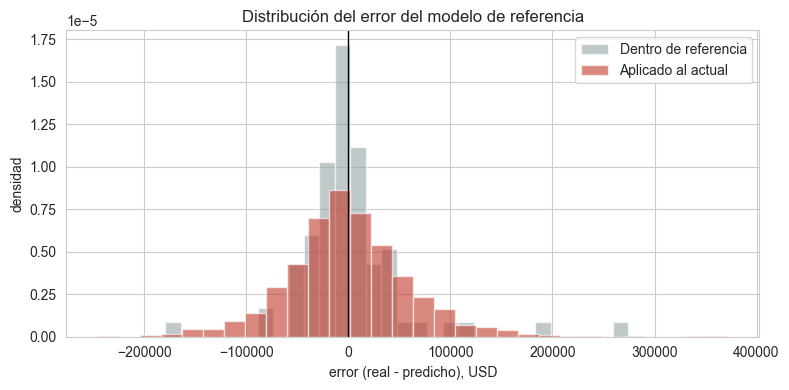

In [11]:
# El sesgo del error dice en qué dirección se equivoca el modelo
error = y_act.values - pred_fuera
print(f'Error medio en el período actual (real - predicho): {error.mean():,.0f} USD')
print(f'Porcentaje de casos subestimados: {(error > 0).mean():.1%}')

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(yr_te.values - pred_dentro, bins=30, alpha=0.6, density=True,
        label='Dentro de referencia', color='#95a5a6')
ax.hist(error, bins=30, alpha=0.6, density=True, label='Aplicado al actual', color='#c0392b')
ax.axvline(0, c='black', lw=1)
ax.set_xlabel('error (real - predicho), USD'); ax.set_ylabel('densidad')
ax.set_title('Distribución del error del modelo de referencia')
ax.legend(); plt.tight_layout(); plt.show()

### Diagnóstico y estrategia

El modelo entrenado solo con la referencia obtiene **R² 0.468** dentro de su propio período y cae a
**R² 0.026** al aplicarlo al período actual. El MAE sube de 31.701 a 44.555 USD. Pierde prácticamente
toda su capacidad explicativa.

Un detalle que conviene no pasar por alto: el error medio es de apenas -886 USD y el 46.7% de los
casos quedan subestimados, es decir **casi no hay sesgo sistemático**. Si solo se mirara el promedio
del error, el modelo parecería sano. Lo que se rompió no es el nivel de las predicciones sino su
capacidad de **discriminar** entre casos, y eso únicamente se ve en el R². Es un buen argumento para
monitorear más de una métrica.

Que el deterioro exista con las features ya desplazadas, y que no se explique por un simple corrimiento
de nivel, es la evidencia de que además del covariate y el label shift hay **concept drift**: el precio
del mismo perfil cambió entre 2021 y 2023.

**Estrategia elegida: reentrenamiento.** De las tres opciones vistas en clase es la que corresponde,
por tres razones:

1. El drift es severo y afecta a la vez a las features y a la target. El *feature engineering* sirve
   cuando el problema es la representación de una variable, no cuando cambió la población entera.
2. Hay volumen suficiente: el período actual tiene 3449 registros contra 306 de la referencia. No es
   un caso donde haya que estirar datos viejos.
3. El deterioro es de discriminación, no de calibración. Un ajuste de nivel o un ensamble ponderado
   no lo arreglaría.

**Qué aporta cada alternativa, para no descartarlas sin fundamento.** Un *ensamble* con ponderación
por recencia tendría sentido si el cambio fuera gradual y se quisiera conservar señal del pasado;
acá la referencia es el 8% de los datos y describe un mercado que ya no existe. El *feature
engineering* sí suma como complemento: normalizar el salario contra la mediana del año convierte el
label shift en una variable estacionaria y haría al modelo menos sensible al próximo salto.

**Una precisión que surge de cruzar las dos secciones.** El drift pesa en proporción a cuánto usa el
modelo cada variable. Según el PFI de la Actividad 1 sobre el modelo sin fuga, `company_size` tiene
una importancia de 0.005, la más baja de todas, y es justamente la de mayor PSI (2.198). Su
desplazamiento, por espectacular que sea, casi no afecta las predicciones. En cambio
`experience_level` combina un PSI alto (0.742) con la segunda importancia más alta (0.212), y ahí sí
el drift se traduce en error. Priorizar el monitoreo por PSI a secas llevaría a mirar primero la
variable equivocada.

## 5. Detección de anomalías

In [12]:
# Variables relevantes para el análisis multivariado. Se usan las numéricas del dataset
# más las categóricas codificadas, sobre el dataset completo.
VARS_ANOMALIA = ['salary_in_usd', 'remote_ratio', 'work_year',
                 'experience_level', 'company_size', 'employment_type']

X_anom = df[VARS_ANOMALIA].copy()
cat_anom = X_anom.select_dtypes(include='object').columns
X_anom[cat_anom] = OrdinalEncoder().fit_transform(X_anom[cat_anom])
X_anom_esc = StandardScaler().fit_transform(X_anom)

CONTAMINACION = 0.01  # 1% esperado de anomalías

iso = IsolationForest(contamination=CONTAMINACION, random_state=42)
etiqueta_iso = iso.fit_predict(X_anom_esc)
score_iso = iso.score_samples(X_anom_esc)

lof = LocalOutlierFactor(n_neighbors=20, contamination=CONTAMINACION)
etiqueta_lof = lof.fit_predict(X_anom_esc)
score_lof = lof.negative_outlier_factor_

anomalias = df.copy()
anomalias['iso_anomalo'] = etiqueta_iso == -1
anomalias['lof_anomalo'] = etiqueta_lof == -1
anomalias['score_iso'] = score_iso
anomalias['score_lof'] = score_lof

print(f'Marcados por Isolation Forest: {anomalias.iso_anomalo.sum()}')
print(f'Marcados por LOF:              {anomalias.lof_anomalo.sum()}')
print(f'Marcados por ambos:            {(anomalias.iso_anomalo & anomalias.lof_anomalo).sum()}')
print(f'Solo por Isolation Forest:     {(anomalias.iso_anomalo & ~anomalias.lof_anomalo).sum()}')
print(f'Solo por LOF:                  {(~anomalias.iso_anomalo & anomalias.lof_anomalo).sum()}')

print('\nTabla de contingencia:')
print(pd.crosstab(anomalias.iso_anomalo, anomalias.lof_anomalo,
                  rownames=['Isolation Forest'], colnames=['LOF']).to_string())

Marcados por Isolation Forest: 38
Marcados por LOF:              38
Marcados por ambos:            0
Solo por Isolation Forest:     38
Solo por LOF:                  38

Tabla de contingencia:
LOF               False  True 
Isolation Forest              
False              3679     38
True                 38      0


In [13]:
# Registro más extremo según Isolation Forest
caso = anomalias.sort_values('score_iso').iloc[0]
idx_caso = caso.name
print(f'Registro {idx_caso} (el más anómalo para Isolation Forest)')
print(f'  marcado por Isolation Forest: {caso.iso_anomalo} | marcado por LOF: {caso.lof_anomalo}')
print()
print(df.loc[[idx_caso]].T.to_string(header=False))

Registro 3675 (el más anómalo para Isolation Forest)
  marcado por Isolation Forest: True | marcado por LOF: False

work_year                               2021
experience_level                          EX
employment_type                           CT
job_title           Principal Data Scientist
salary                                416000
salary_currency                          USD
salary_in_usd                         416000
employee_residence                        US
remote_ratio                             100
company_location                          US
company_size                               S


In [14]:
# ¿Es un outlier univariado? Se mira cada variable por separado contra su propia distribución
print('Posición del registro en cada variable:\n')
for v in VARS_ANOMALIA:
    valor = df.loc[idx_caso, v]
    if df[v].dtype == object:
        frec = (df[v] == valor).mean()
        print(f'  {v:18} = {str(valor):10} -> aparece en el {frec:.2%} del dataset')
    else:
        pct = (df[v] < valor).mean()
        z = (valor - df[v].mean()) / df[v].std()
        print(f'  {v:18} = {valor:>10,.0f} -> percentil {pct:.1%}, z = {z:+.2f}')

Posición del registro en cada variable:

  salary_in_usd      =    416,000 -> percentil 99.9%, z = +4.42
  remote_ratio       =        100 -> percentil 56.2%, z = +1.11
  work_year          =      2,021 -> percentil 2.0%, z = -1.99
  experience_level   = EX         -> aparece en el 3.04% del dataset
  company_size       = S          -> aparece en el 3.94% del dataset
  employment_type    = CT         -> aparece en el 0.27% del dataset


In [15]:
# Comparación con el grupo al que pertenece: misma experiencia y mismo tamaño de empresa
grupo = df[(df.experience_level == df.loc[idx_caso, 'experience_level']) &
           (df.company_size == df.loc[idx_caso, 'company_size'])]
print(f'Grupo de comparación: experience_level={df.loc[idx_caso, "experience_level"]}, '
      f'company_size={df.loc[idx_caso, "company_size"]} ({len(grupo)} registros)')
print(grupo.salary_in_usd.describe().to_string())
print(f'\nSalario del registro: {df.loc[idx_caso, "salary_in_usd"]:,.0f} USD')
print(f'Percentil dentro de su grupo: {(grupo.salary_in_usd < df.loc[idx_caso, "salary_in_usd"]).mean():.1%}')

Grupo de comparación: experience_level=EX, company_size=S (6 registros)
count         6.000000
mean     196827.166667
std      119289.827845
min       69741.000000
25%      131416.500000
50%      190000.000000
75%      200000.000000
max      416000.000000

Salario del registro: 416,000 USD
Percentil dentro de su grupo: 83.3%


In [16]:
# Un caso donde los métodos NO coinciden, para contrastar su lógica
solo_lof = anomalias[~anomalias.iso_anomalo & anomalias.lof_anomalo]
print(f'Registros marcados solo por LOF: {len(solo_lof)}')
if len(solo_lof):
    idx_lof = solo_lof.sort_values('score_lof').index[0]
    print(f'\nRegistro {idx_lof} (el más anómalo para LOF entre los que Isolation Forest no marca):')
    print(df.loc[[idx_lof]].T.to_string(header=False))
    print('\nPosición en cada variable:')
    for v in VARS_ANOMALIA:
        valor = df.loc[idx_lof, v]
        if df[v].dtype == object:
            print(f'  {v:18} = {str(valor):10} -> {(df[v] == valor).mean():.2%} del dataset')
        else:
            pct = (df[v] < valor).mean()
            print(f'  {v:18} = {valor:>10,.0f} -> percentil {pct:.1%}')

Registros marcados solo por LOF: 38

Registro 2476 (el más anómalo para LOF entre los que Isolation Forest no marca):
work_year                   2022
experience_level              SE
employment_type               FT
job_title           Data Analyst
salary                    127000
salary_currency              USD
salary_in_usd             127000
employee_residence            US
remote_ratio                   0
company_location              US
company_size                   M

Posición en cada variable:
  salary_in_usd      =    127,000 -> percentil 43.8%
  remote_ratio       =          0 -> percentil 0.0%
  work_year          =      2,022 -> percentil 8.1%
  experience_level   = SE         -> 67.00% del dataset
  company_size       = M          -> 83.97% del dataset
  employment_type    = FT         -> 99.01% del dataset


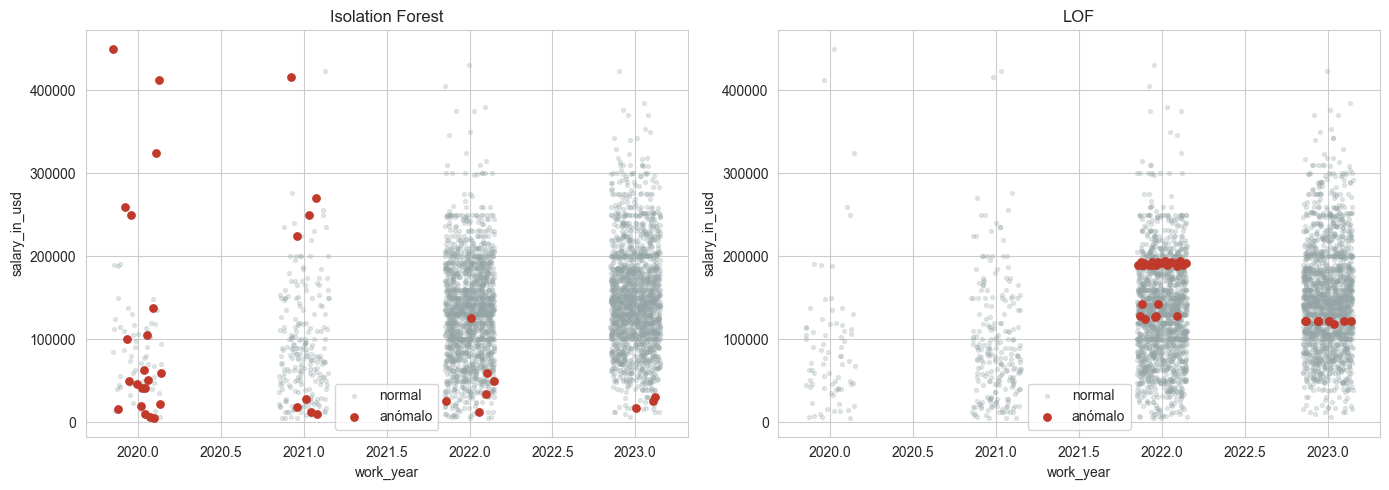

In [17]:
# Visualización: dónde caen los registros marcados
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (col, titulo) in zip(axes, [('iso_anomalo', 'Isolation Forest'), ('lof_anomalo', 'LOF')]):
    normales = anomalias[~anomalias[col]]
    marcados  = anomalias[anomalias[col]]
    ax.scatter(normales.work_year + np.random.uniform(-.15, .15, len(normales)),
               normales.salary_in_usd, s=8, alpha=0.25, color='#95a5a6', label='normal')
    ax.scatter(marcados.work_year + np.random.uniform(-.15, .15, len(marcados)),
               marcados.salary_in_usd, s=28, color='#c0392b', label='anómalo')
    ax.set_title(titulo); ax.set_xlabel('work_year'); ax.set_ylabel('salary_in_usd')
    ax.legend()
plt.tight_layout(); plt.show()

### Lectura de la detección de anomalías

**Los dos métodos marcan 38 registros cada uno y no coinciden en ninguno.** La tabla de contingencia
lo confirma: la celda de acuerdo está en cero. Lejos de ser un error, es el resultado más informativo
de esta sección, porque muestra que no miden lo mismo.

**El caso marcado por Isolation Forest (registro 3675).** Un `Principal Data Scientist` de nivel
ejecutivo (EX), contratado (CT), en una empresa chica (S) de Estados Unidos, con 416.000 USD en 2021.

Es un outlier **univariado y multivariado a la vez**:

- Univariado: el salario está en el percentil 99.9, a 4.42 desvíos de la media.
- Multivariado: la combinación es rara por partida doble. `employment_type = CT` aparece en el 0.27%
  del dataset, `experience_level = EX` en el 3.04% y `company_size = S` en el 3.94%. Un ejecutivo
  contratado en una empresa chica cobrando como el 0.1% superior es una conjunción poco frecuente.

Lo interesante es el contraste con su propio grupo: entre los 6 registros de perfil EX en empresas
chicas, su salario está en el percentil 83.3, es decir alto pero no excepcional. **Globalmente
extremo, localmente normal.** Esa es exactamente la razón por la que LOF no lo marca.

**El caso marcado solo por LOF (registro 2476).** Un `Data Analyst` senior, full time, en una empresa
mediana de Estados Unidos, con 127.000 USD. Ninguno de sus valores es raro: el salario está en el
percentil 43.8, `SE` cubre el 67% del dataset, `M` el 84% y `FT` el 99%.

Su `remote_ratio = 0` figura en el percentil 0.0%, y conviene no leerlo como rareza: el 51.2% del
dataset tiene exactamente ese valor, así que el percentil 0 solo refleja que es el mínimo de una
variable discreta de tres niveles. Es el valor **más frecuente** de la columna. El percentil es una
métrica engañosa en variables discretas, y vale tenerlo presente al interpretar la tabla anterior.

Visto de a una variable, entonces, es un registro perfectamente común, y sin embargo su vecindario es
menos denso que el de sus vecinos. Ahí está la diferencia con el caso anterior.

**Por qué difieren.** Responde a la lógica de cada algoritmo:

- **Isolation Forest** aísla puntos con cortes aleatorios y mide cuántos cortes hacen falta para
  separarlos. Un valor extremo se aísla en pocos cortes, así que el método es **global**: encuentra lo
  que está lejos del grueso de los datos en el espacio completo.
- **LOF** compara la densidad local de cada punto con la de sus k vecinos. No le importa si el punto
  es extremo en términos absolutos, sino si está más aislado que quienes lo rodean. Es una medida
  **relativa al vecindario**.

Con un dataset dominado por variables categóricas de pocos niveles, los puntos se apilan en grupos
densos. Isolation Forest se queda con las combinaciones globalmente raras y los salarios extremos;
LOF, con los registros que caen en los bordes de esos grupos. Que no se superpongan es consistente
con lo que mide cada uno, no una contradicción.

**Qué hacer con esto.** No se trata de errores a eliminar: son perfiles legítimos. Lo que corresponde
es tratarlos como señal. Los casos que marca Isolation Forest conviene revisarlos antes de entrenar,
porque un salario a 4.4 desvíos influye en los cortes de un árbol. Los de LOF son más útiles como
alerta de cobertura: indican zonas del espacio donde el modelo tiene pocos ejemplos y, por lo tanto,
predicciones menos confiables.

## 6. Conclusiones

**Calidad.** El dataset está limpio en completitud, validez, rango y consistencia, y falla en
unicidad: 33.9% de filas duplicadas en el período actual contra 1.0% en la referencia. Sin una
columna identificadora no puede afirmarse que toda repetición sea un error, pero el volumen obliga a
deduplicar antes de entrenar para que las copias no crucen de entrenamiento a test.

**Drift.** Las cuatro variables analizadas superan ampliamente el umbral de 0.25: `company_size`
(2.198), `remote_ratio` (1.191), `salary_in_usd` (0.863) y `experience_level` (0.742). Hay covariate
shift en las features y label shift en la target, y la caída del modelo de R² 0.468 a 0.026 agrega
evidencia de concept drift, que el PSI por sí solo no puede detectar.

**Estrategia.** Reentrenar con los datos del período actual, que además son diez veces más
abundantes. Como complemento, normalizar el salario contra la mediana anual para que el próximo
desplazamiento de nivel no vuelva a degradar el modelo. Y priorizar el monitoreo por el producto
entre drift e importancia, no por el PSI solo: la variable más desplazada resultó ser la menos usada
por el modelo.

**Anomalías.** Isolation Forest y LOF marcaron 38 registros cada uno sin superponerse en ninguno, lo
que ilustra la diferencia entre una medida global de aislamiento y una local de densidad. El caso más
extremo para Isolation Forest es globalmente atípico pero normal dentro de su grupo de pares, que es
justamente lo que explica que LOF no lo señale.